# Step 1

In [92]:
!pip install ucimlrepo


In [93]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    LogisticRegression
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [94]:
forest_fires = fetch_ucirepo(id=162)

X = forest_fires.data.features
y = forest_fires.data.targets

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0



Target:


,area
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [95]:
print(X.info())


<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), str(2)
memory usage: 48.6 KB
None


In [96]:
print(X.describe())


                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   
min      1.000000    2.000000   18.700000    1.100000    7.900000    0.000000   
25%      3.000000    4.000000   90.200000   68.600000  437.700000    6.500000   
50%      4.000000    4.000000   91.600000  108.300000  664.200000    8.400000   
75%      7.000000    5.000000   92.900000  142.400000  713.900000   10.800000   
max      9.000000    9.000000   96.200000  291.300000  860.600000   56.100000   

             temp          RH        wind        rain  
count  517.000000  517.000000  517.000000  517.000000  
mean    18.889168   44.288201    4.017602    0.021663  
std      5.806625   16.317469    1.791653    0.295959  
min      2.200000   15.000000    0.400000    0

In [97]:
print(y.head())

   area
0   0.0
1   0.0
2   0.0
3   0.0
4   0.0


# Step 2- EDA

In [98]:
# Display the target variable
print("Target variable:")
print(y.head())


Target variable:
   area
0   0.0
1   0.0
2   0.0
3   0.0
4   0.0


In [99]:

# Summary statistics for fire area
print("\nSummary statistics for fire area:")
print(y.describe())



Summary statistics for fire area:
              area
count   517.000000
mean     12.847292
std      63.655818
min       0.000000
25%       0.000000
50%       0.520000
75%       6.570000
max    1090.840000


In [100]:

# Count zero-area fires
zero_fires = (y["area"] == 0).sum()

print(f"\nNumber of fires with zero burned area: {zero_fires}")
print(f"Percentage of zero-area observations: {zero_fires / len(y) * 100:.2f}%")


Number of fires with zero burned area: 247
Percentage of zero-area observations: 47.78%


- The area variable represents the burned area of the forest.

- This dataset shows that many observations have an area of 0. Meaning the distribution is heavily skewed.

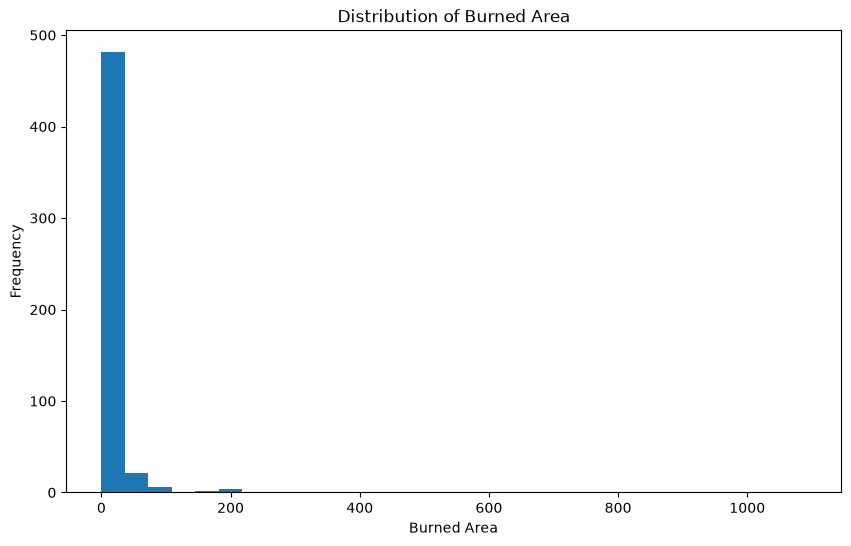

In [101]:
# Histogram showing the distribution of fire area

plt.figure(figsize=(10, 6))
plt.hist(y["area"], bins=30)
plt.xlabel("Burned Area")
plt.ylabel("Frequency")
plt.title("Distribution of Burned Area")
plt.show()

- The target is strongly right-skewed, with many fires having relatively small burned areas and a smaller number of very large fires

In [102]:
# Examine the predictors (features and target variable)
X.describe(include="all")

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
count,517.000000,517.000000,517,517,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
unique,NaN,NaN,12,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,aug,sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,184,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.669246,4.299807,NaN,NaN,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663
std,2.313778,1.229900,NaN,NaN,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959
min,1.000000,2.000000,NaN,NaN,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000
25%,3.000000,4.000000,NaN,NaN,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000
50%,4.000000,4.000000,NaN,NaN,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000
75%,7.000000,5.000000,NaN,NaN,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000


In [103]:
# Unique values for categorical variables
print("Months:")
print(X["month"].unique())

print("\nDays:")
print(X["day"].unique())

Months:
<StringArray>
['mar', 'oct', 'aug', 'sep', 'apr', 'jun', 'jul', 'feb', 'jan', 'dec', 'may',
 'nov']
Length: 12, dtype: str

Days:
<StringArray>
['fri', 'tue', 'sat', 'sun', 'mon', 'wed', 'thu']
Length: 7, dtype: str


In [104]:
# Conversion of the target to a DataFrame
df = X.copy()

df["area"] = y["area"]

df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [105]:
# Correlation analysis
numeric_df = df.select_dtypes(include=["number"])

correlation = numeric_df.corr()

print(correlation["area"].sort_values(ascending=False))

area    1.000000
temp    0.097844
DMC     0.072994
X       0.063385
DC      0.049383
Y       0.044873
FFMC    0.040122
wind    0.012317
ISI     0.008258
rain   -0.007366
RH     -0.075519
Name: area, dtype: float64


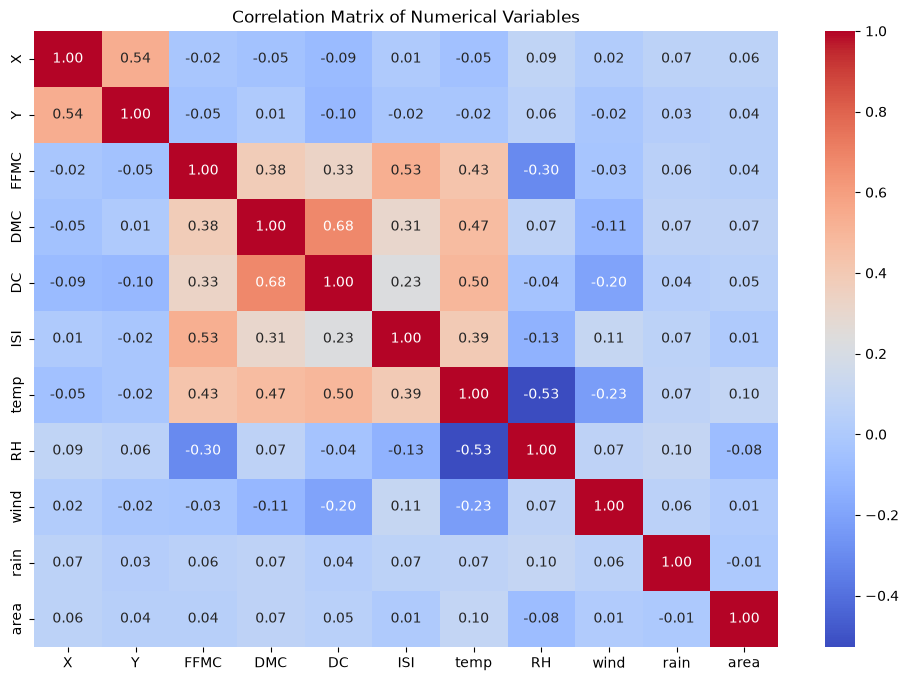

In [106]:
# correlation heatmap


plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Correlation Findings

The correlation matrix was used to identify linear relationships between the environmental variables and fire size.

The results show that there were no environmental variables that have meaningful linear relationship with `log_area`. The strongest absolute correlations were negligible: DMC and DC (both at +0.07), followed by RH at -0.05. Suggesting that fire size is not driven by simple linear trends.

Since correlation does not establish causation, these relationships will be evaluated further through modelling to capture potential threshold effects and interactions between variables.

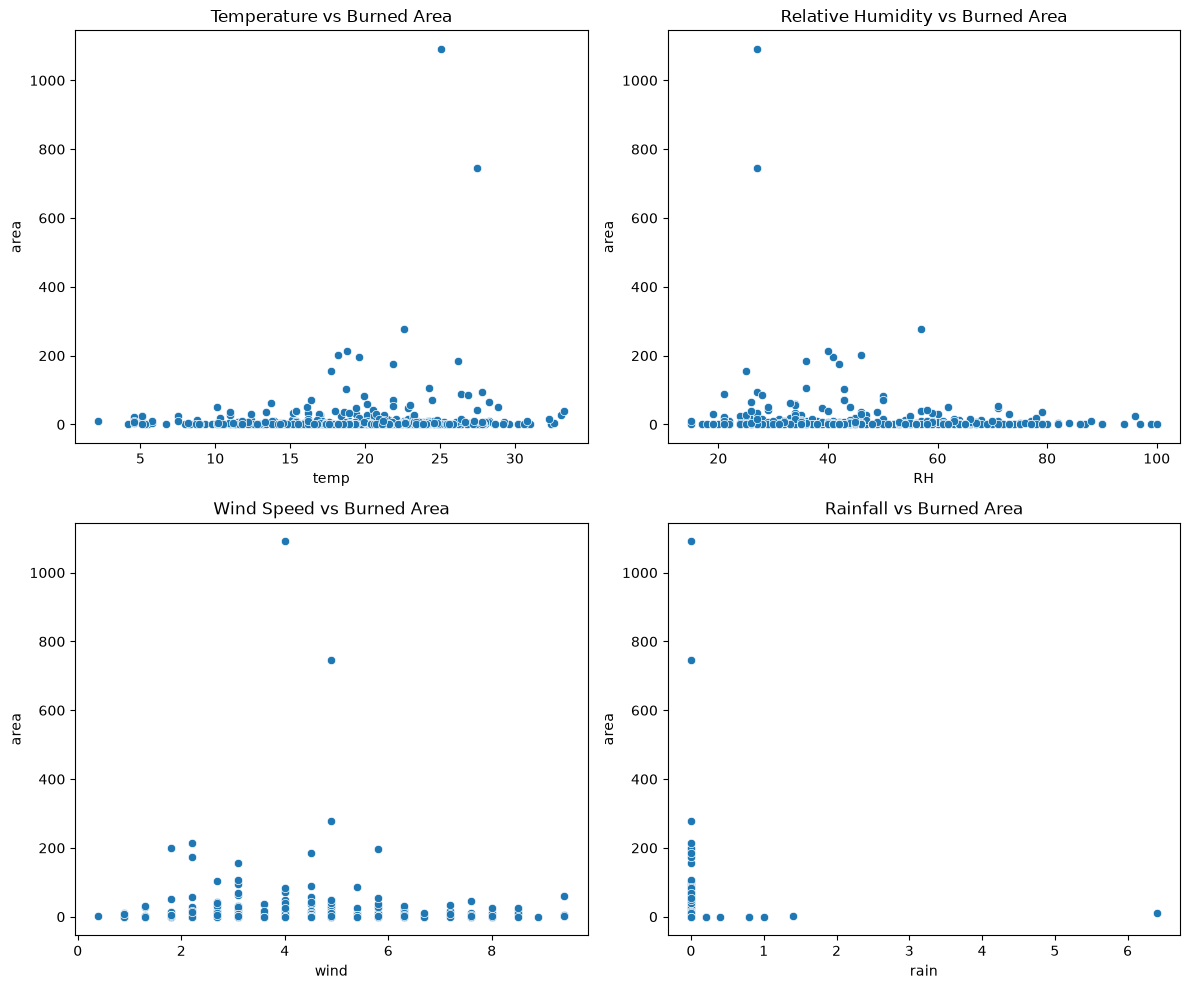

In [107]:
# Scatter plots for numerical variables against the target variable
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(data=df, x="temp", y="area", ax=axes[0, 0])
axes[0, 0].set_title("Temperature vs Burned Area")

sns.scatterplot(data=df, x="RH", y="area", ax=axes[0, 1])
axes[0, 1].set_title("Relative Humidity vs Burned Area")

sns.scatterplot(data=df, x="wind", y="area", ax=axes[1, 0])
axes[1, 0].set_title("Wind Speed vs Burned Area")

sns.scatterplot(data=df, x="rain", y="area", ax=axes[1, 1])
axes[1, 1].set_title("Rainfall vs Burned Area")

plt.tight_layout()
plt.show()

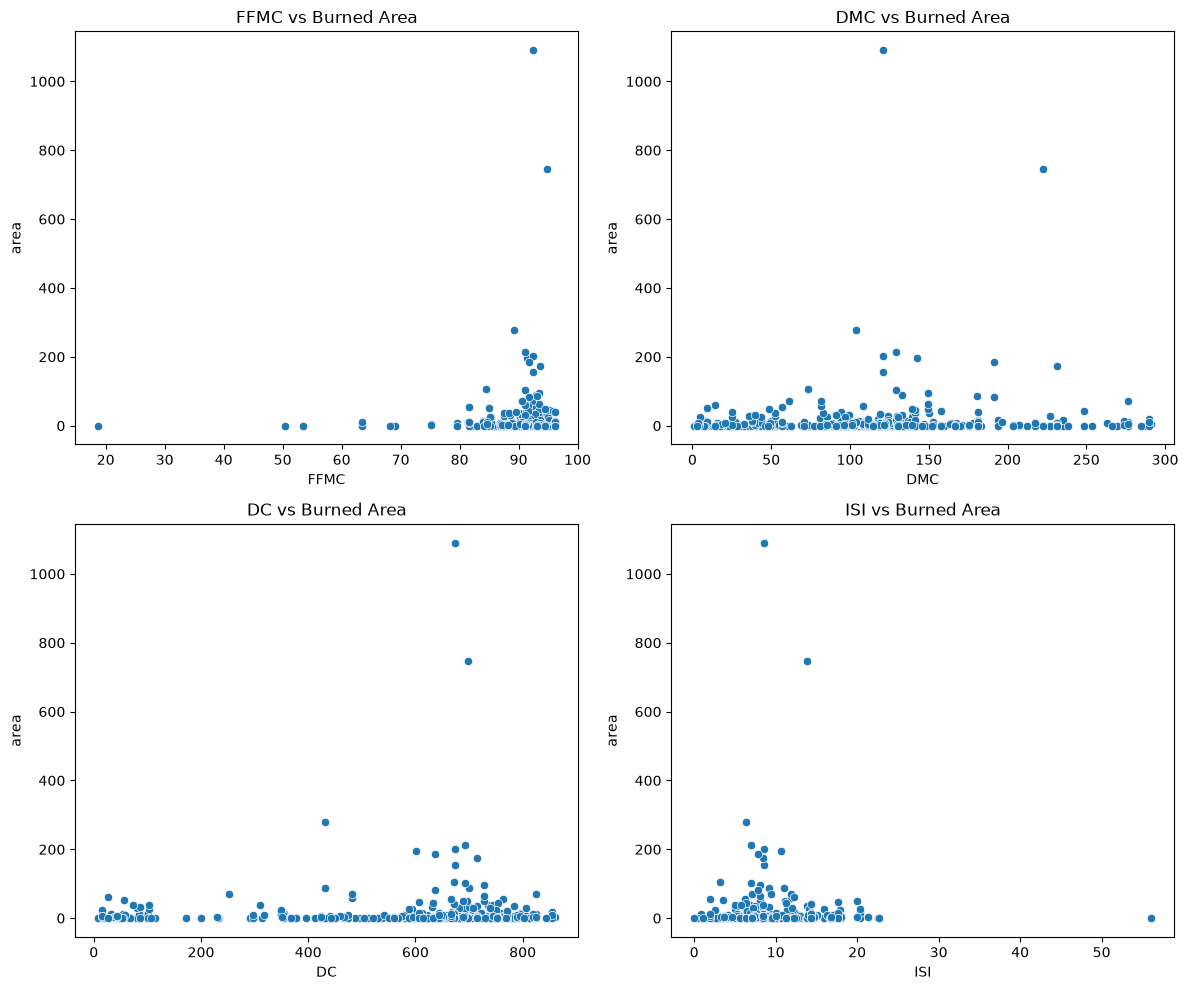

In [108]:
# Scatter plots for numerical variables against the target variable (Fire weather indices)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(data=df, x="FFMC", y="area", ax=axes[0, 0])
axes[0, 0].set_title("FFMC vs Burned Area")

sns.scatterplot(data=df, x="DMC", y="area", ax=axes[0, 1])
axes[0, 1].set_title("DMC vs Burned Area")

sns.scatterplot(data=df, x="DC", y="area", ax=axes[1, 0])
axes[1, 0].set_title("DC vs Burned Area")

sns.scatterplot(data=df, x="ISI", y="area", ax=axes[1, 1])
axes[1, 1].set_title("ISI vs Burned Area")

plt.tight_layout()
plt.show()

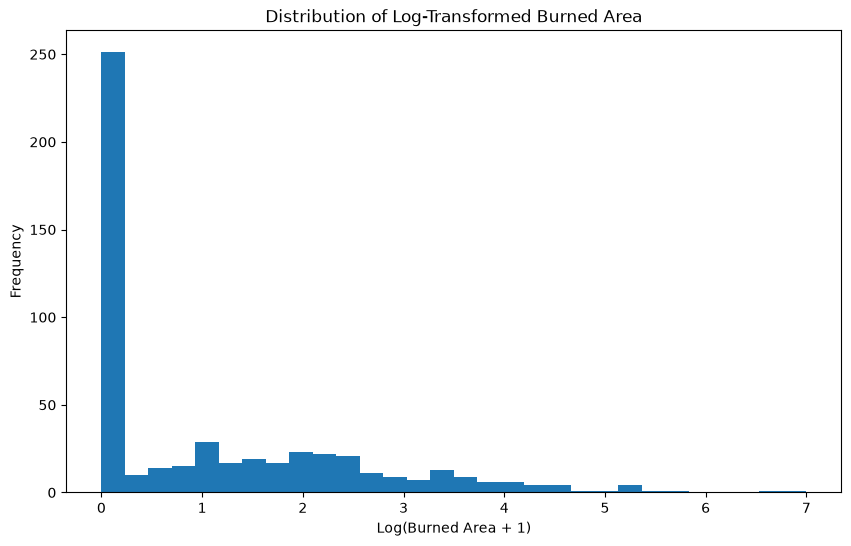

In [109]:

# Log transformation of the target variable

df["log_area"] = np.log1p(df["area"])

plt.figure(figsize=(10, 6))

plt.hist(df["log_area"], bins=30)

plt.xlabel("Log(Burned Area + 1)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Burned Area")

plt.show()

#### Target distribution

- The original fire-area variable is strongly right-skewed, indicating that most observations correspond to relatively small fires while a small number of observations represent larger fires.

- A log transformation reduces the influence of extreme observations and produces a more balanced target distribution. Hence, the transformed target will be used for regression analysis.

# Step 3

In [126]:
# Create a modelling dataframe
model_df = X.copy()

# Add the target variable
model_df["area"] = y["area"]

# Log-transform the target because fire area is highly right-skewed
model_df["log_area"] = np.log1p(model_df["area"])

# Convert categorical variables into dummy variables
model_df = pd.get_dummies(
    model_df,
    columns=["month", "day"],
    drop_first=True,
    dtype=int
)

# Log-transform highly right-skewed predictors
model_df["log_rain"] = np.log1p(model_df["rain"])
model_df["log_ISI"] = np.log1p(model_df["ISI"])

# Add quadratic terms to capture nonlinear relationships
model_df["temp_squared"] = model_df["temp"] ** 2
model_df["wind_squared"] = model_df["wind"] ** 2

# Add interaction terms
model_df["temp_RH_interaction"] = (
    model_df["temp"] * model_df["RH"]
)

model_df["wind_FFMC_interaction"] = (
    model_df["wind"] * model_df["FFMC"]
)

# Display the first few rows
model_df.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,day_sun,day_thu,day_tue,day_wed,log_rain,log_ISI,temp_squared,wind_squared,temp_RH_interaction,wind_FFMC_interaction
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,0,0,0,0,0.000000,1.808289,67.24,44.89,418.2,577.54
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,0,0,1,0,0.000000,2.041220,324.00,0.81,594.0,81.54
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,0,0,0,0,0.000000,2.041220,213.16,1.69,481.8,117.78
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,0,0,0,0,0.182322,2.302585,68.89,16.00,805.1,366.80
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,1,0,0,0,0.000000,2.360854,129.96,3.24,1128.6,160.74


In [134]:
# Define the original predictors for the baseline model
baseline_features = [
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "temp",
    "RH",
    "wind",
    "rain"
]

X_baseline = model_df[baseline_features]
y_model = model_df["log_area"]

# Split the baseline data into training and testing sets
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline,
    y_model,
    test_size=0.20,
    random_state=42
)

# Create and fit the baseline multiple linear regression model
baseline_model = LinearRegression()

baseline_model.fit(
    X_train_base,
    y_train_base
)

# Make predictions
baseline_pred = baseline_model.predict(X_test_base)

# Evaluate the baseline model
baseline_mse = mean_squared_error(
    y_test_base,
    baseline_pred
)

baseline_r2 = r2_score(
    y_test_base,
    baseline_pred
)

print("Baseline Regression Model")
print(f"MSE: {baseline_mse:.4f}")
print(f"R²: {baseline_r2:.4f}")

Baseline Regression Model
MSE: 2.1911
R²: 0.0031


In [128]:
# Separate predictors and target for the improved model

X_model = model_df.drop(
    columns=["area", "log_area"]
)

y_model = model_df["log_area"]

print("Predictors:", X_model.shape)
print("Target:", y_model.shape)

Predictors: (517, 33)
Target: (517,)


In [129]:
# Split the improved model data

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (413, 33)
Testing set: (104, 33)


In [132]:
# Create and fit the improved multiple linear regression model

improved_model = LinearRegression()

improved_model.fit(
    X_train,
    y_train
)

# Make predictions on the test set
y_pred = improved_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Improved Regression Model")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

Improved Regression Model
MSE: 2.3878
R²: -0.0864


In [133]:
# Compare the baseline and improved models

print("Model Comparison")
print(f"Baseline MSE:  {baseline_mse:.4f}")
print(f"Improved MSE:  {mse:.4f}")
print()
print(f"Baseline R²:   {baseline_r2:.4f}")
print(f"Improved R²:   {r2:.4f}")

Model Comparison
Baseline MSE:  2.1911
Improved MSE:  2.3878

Baseline R²:   0.0031
Improved R²:   -0.0864


# Step 4

In [135]:
# Calculate adjusted R² for both models

def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))


# Baseline model
n_base = len(y_test_base)
p_base = X_test_base.shape[1]

baseline_adj_r2 = adjusted_r2(
    baseline_r2,
    n_base,
    p_base
)


# Improved model
n_improved = len(y_test)
p_improved = X_test.shape[1]

improved_adj_r2 = adjusted_r2(
    r2,
    n_improved,
    p_improved
)


print("R² and Adjusted R²")
print("-------------------")
print(f"Baseline R²:          {baseline_r2:.4f}")
print(f"Baseline Adjusted R²: {baseline_adj_r2:.4f}")
print()
print(f"Improved R²:          {r2:.4f}")
print(f"Improved Adjusted R²: {improved_adj_r2:.4f}")

R² and Adjusted R²
-------------------
Baseline R²:          0.0031
Baseline Adjusted R²: -0.0809

Improved R²:          -0.0864
Improved Adjusted R²: -0.5986


In [136]:
# Calculate AIC and BIC for both models

def calculate_aic_bic(y_true, y_pred, p):
    n = len(y_true)

    residuals = y_true - y_pred

    rss = np.sum(residuals ** 2)

    # Number of estimated parameters includes the intercept
    k = p + 1

    aic = n * np.log(rss / n) + 2 * k

    bic = n * np.log(rss / n) + k * np.log(n)

    return aic, bic


# Baseline model
baseline_aic, baseline_bic = calculate_aic_bic(
    y_test_base,
    baseline_pred,
    p_base
)


# Improved model
improved_aic, improved_bic = calculate_aic_bic(
    y_test,
    y_pred,
    p_improved
)


print("AIC and BIC")
print("-----------")
print(f"Baseline AIC: {baseline_aic:.4f}")
print(f"Baseline BIC: {baseline_bic:.4f}")
print()
print(f"Improved AIC: {improved_aic:.4f}")
print(f"Improved BIC: {improved_bic:.4f}")

AIC and BIC
-----------
Baseline AIC: 99.5771
Baseline BIC: 123.3767

Improved AIC: 158.5183
Improved BIC: 248.4275


In [138]:
# Model comparison summary

model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Improved"
    ],
    "R²": [
        baseline_r2,
        r2
    ],
    "Adjusted R²": [
        baseline_adj_r2,
        improved_adj_r2
    ],
    "AIC": [
        baseline_aic,
        improved_aic
    ],
    "BIC": [
        baseline_bic,
        improved_bic
    ]
})

model_comparison

,Model,R²,Adjusted R²,AIC,BIC
0,Baseline,0.003085,-0.080866,99.577140,123.376658
1,Improved,-0.086415,-0.598582,158.518254,248.427544


For R², the improved model having a negative R² means it performs worse on the test data than simply predicting the mean target value.

Also, lower AIC and BIC are preferred, so both strongly favor the baseline model.

Hence, based on the current test-set results, the additional transformations, quadratic terms, interactions, and dummy variables did not improve predictive performance.

In [139]:
# Calculate residuals for the improved model

residuals = y_test - y_pred

print("Residual Summary")
print("----------------")
print(residuals.describe())

Residual Summary
----------------
count    104.000000
mean       0.117407
std        1.548242
min       -3.705230
25%       -1.009940
50%       -0.492007
75%        0.888758
max        5.239760
Name: log_area, dtype: float64


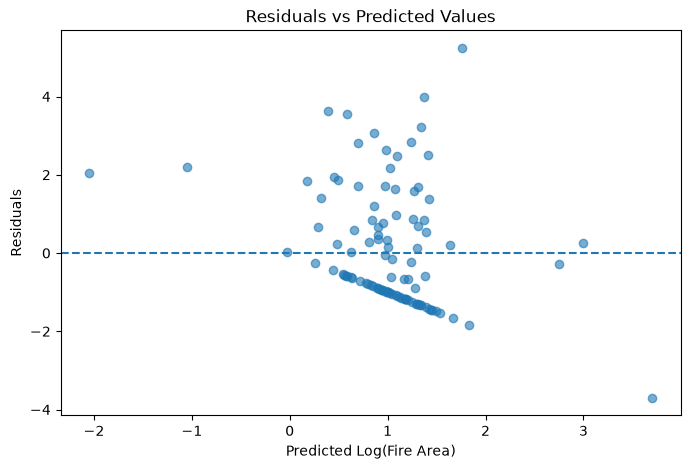

In [140]:
# Residual plot

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Log(Fire Area)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

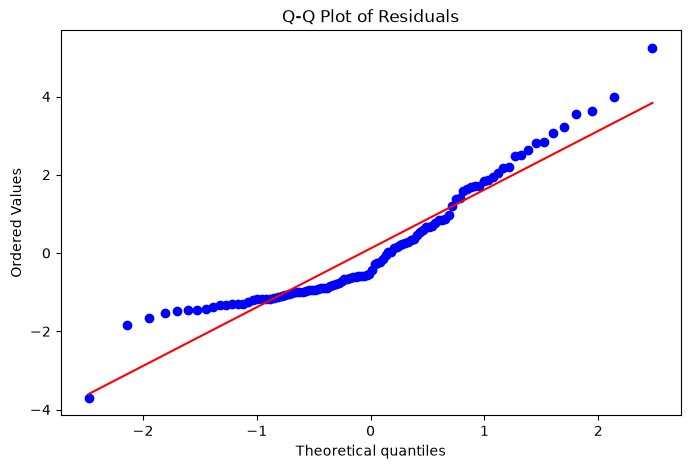

In [152]:
# Q-Q plot to assess residual normality


plt.figure(figsize=(8, 5))
stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)
plt.title("Q-Q Plot of Residuals")
plt.show()

### Q-Q Plot Interpretation

- The Q-Q plot shows that the residuals are not perfectly normally distributed. 
Although the points follow the reference line reasonably well in the middle 
of the distribution, there are deviations at both tails. The 
upper tail show strong deviation, indicating the presence of 
large positive residuals and possible outliers.
- Hence, the normality assumption of the regression model is only partially 
satisfied. The deviations suggest that the model may not fully capture the 
distribution of the fire-area data, even after applying the log transformation.

In [153]:
# Calculate Cook's Distance using the training data


# Add an intercept
X_train_sm = sm.add_constant(X_train)

# Fit the improved model using statsmodels
ols_model = sm.OLS(
    y_train,
    X_train_sm
).fit()

# Calculate influence measures
influence = ols_model.get_influence()

cooks_distance = influence.cooks_distance[0]

print("Cook's Distance Summary")
print(pd.Series(cooks_distance).describe())

Cook's Distance Summary
count    4.120000e+02
mean     6.380518e-01
std      1.169305e+01
min      4.466604e-11
25%      3.675746e-04
50%      8.949350e-04
75%      1.903921e-03
max      2.367153e+02
dtype: float64


c:\Users\HomePC\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


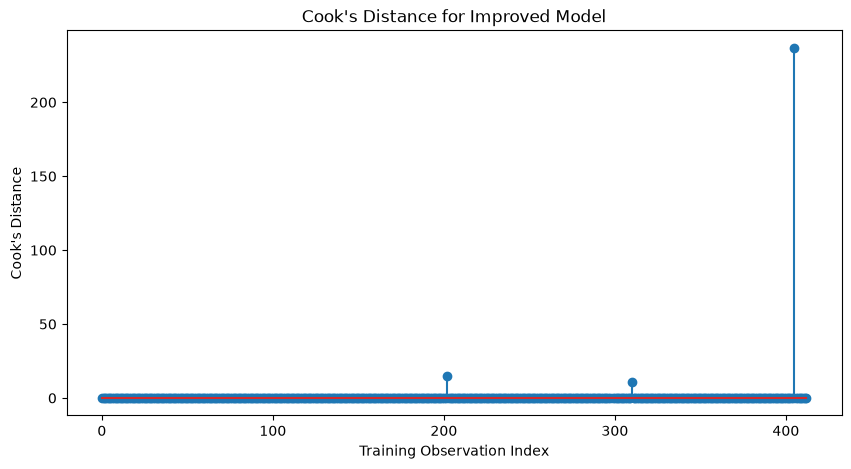

In [148]:
# Plot Cook's Distance

plt.figure(figsize=(10, 5))
plt.stem( range(len(cooks_distance)), cooks_distance)
plt.xlabel("Training Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Improved Model")
plt.show()

In [149]:
# Identify potentially influential observations

n_train = len(y_train)

cook_threshold = 4 / n_train

influential_indices = np.where(
    cooks_distance > cook_threshold
)[0]

print(f"Number of training observations: {n_train}")
print(f"Cook's Distance threshold: {cook_threshold:.4f}")
print(
    f"Number of potentially influential observations: "
    f"{len(influential_indices)}"
)

print("\nInfluential observation indices:")
print(influential_indices)

Number of training observations: 413
Cook's Distance threshold: 0.0097
Number of potentially influential observations: 23

Influential observation indices:
[ 15  18  63  66  71  92 117 136 183 195 202 204 206 233 262 300 306 310
 339 366 368 377 405]


In [150]:
# Display influential observations

influential_observations = pd.DataFrame({
    "Observation_Index": influential_indices,
    "Cooks_Distance": cooks_distance[influential_indices]
}).sort_values(
    by="Cooks_Distance",
    ascending=False
)

influential_observations

,Observation_Index,Cooks_Distance
22,405,236.715345
10,202,14.701821
17,310,10.602854
5,92,0.043871
2,63,0.023571
15,300,0.021501
19,366,0.019871
12,206,0.018246
14,262,0.016428
13,233,0.016080


### Observation
- Cook's Distance Analysis: Cook's Distance was used to identify observations that may have a substantial influence on the fitted regression model. Using a threshold of \(4/n\), where \(n=413\), the threshold was approximately 0.0097. A total of 23 observations exceeded this threshold. Most had relatively small Cook's Distance values, but observations 405, 202, and 310 were particularly influential, with Cook's Distance values of approximately 236.72, 14.70, and 10.60 respectively.

# Step 5- Apply Regularization


Ridge (L2) and Lasso (L1) regression are regularization techniques used to reduce the impact of multicollinearity and prevent overfitting.

Ridge regression shrinks coefficients toward zero but generally keeps all predictors in the model. Lasso regression can shrink some coefficients exactly to zero, effectively performing feature selection.

Both models will be evaluated using Mean Squared Error (MSE), and their coefficients will be compared.

In [156]:
# Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

# Lasso Regression
lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train, y_train)

# Predictions
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

# Calculate MSE
ridge_mse = mean_squared_error(y_test, ridge_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)

print("Ridge MSE:", ridge_mse)
print("Lasso MSE:", lasso_mse)

Ridge MSE: 2.209639100531216
Lasso MSE: 2.1254235824387213


In [157]:
# Extract coefficients
ridge_coefficients = pd.Series(
    ridge_model.coef_,
    index=X_train.columns
)

lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=X_train.columns
)

# Combine coefficients into a single table
coefficient_comparison = pd.DataFrame({
    "Ridge": ridge_coefficients,
    "Lasso": lasso_coefficients
})

coefficient_comparison

,Ridge,Lasso
X,0.051813,0.029825
Y,0.002917,0.000000
FFMC,-0.009370,0.009902
DMC,0.004174,0.001885
DC,-0.001330,0.000205
ISI,-0.094556,-0.023563
temp,-0.289401,-0.053207
RH,-0.030525,-0.000000
wind,0.232564,0.000000
rain,0.291835,0.000000


In [158]:
# Compare model performance
model_comparison = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],
    "MSE": [ridge_mse, lasso_mse]
})

model_comparison

,Model,MSE
0,Ridge,2.209639
1,Lasso,2.125424


In [159]:
# Identify features removed by Lasso
zero_lasso_coefficients = lasso_coefficients[lasso_coefficients == 0]

print("Number of coefficients reduced to zero by Lasso:",
      len(zero_lasso_coefficients))

print("\nFeatures removed by Lasso:")
print(zero_lasso_coefficients.index.tolist())

Number of coefficients reduced to zero by Lasso: 23

Features removed by Lasso:
['Y', 'RH', 'wind', 'rain', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_mon', 'day_sat', 'day_sun', 'day_thu', 'day_tue', 'day_wed', 'log_rain', 'log_ISI']


 ### Conclusion :Ridge and Lasso Regression 

- Ridge and Lasso regression were applied to address multicollinearity and reduce the risk of overfitting. The Ridge model produced a Mean Squared Error (MSE) of **2.2096**, while the Lasso model produced a lower MSE of **2.1254** on the test set. Since a lower MSE indicates better predictive performance, the Lasso model performed better than the Ridge model.

- Ridge regression shrank the model coefficients toward zero while retaining all predictors. In contrast, Lasso regression performed both regularization and feature selection. Lasso reduced **23 of the 34 coefficients to zero**, effectively removing these predictors from the model. The remaining predictors retained non-zero coefficients, which includes `X`, `FFMC`, `DMC`, `DC`, `ISI`, `temp`, `temp_squared`, `wind_squared`, and the interaction terms.

- The results indicate that Lasso provided a simpler model while achieving slightly better predictive performance than Ridge regression . The lower MSE suggests that the Lasso model generalized better to the test data in this analysis. However, the zero coefficients should not automatically be interpreted as proof that those variables have no relationship with the target; they indicate that Lasso did not find sufficient additional predictive value from those variables under the selected regularization strength.

- Hence, **Lasso regression was the better-performing model in this comparison**, with an MSE of **2.1254** compared with **2.2096** for Ridge.


# Step 6

- The continuous target variable area will be converted into a binary target using its median as the threshold. Observations with an area value that is greater than the median will be classified as 1, representing higher burned area, while observations at or below the median will be classified as 0, representing lower burned area.
- Relevant numerical predictors will then be selected and standardized using StandardScaler for the predictors to have a mean of approximately 0 and a standard deviation of approximately 1.

In [160]:
# Calculate the median of the target variable
median_area = y.median()

print("Median area:", median_area)

# Create binary target
y_binary = (y > median_area).astype(int)

# Check class distribution
print("\nBinary target distribution:")
print(y_binary.value_counts())

print("\nBinary target proportions:")
print(y_binary.value_counts(normalize=True))

Median area: area    0.52
dtype: float64

Binary target distribution:
area
0       259
1       258
Name: count, dtype: int64

Binary target proportions:
area
0       0.500967
1       0.499033
Name: proportion, dtype: float64


In [162]:
# Selection of relevant numerical predictors
selected_features = [
    "X",
    "Y",
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "temp",
    "RH",
    "wind",
    "rain"
]

X_classification = X[selected_features].copy()

print("Selected predictors:")
print(X_classification.columns.tolist())

print("\nShape of predictor dataset:")
print(X_classification.shape)

Selected predictors:
['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']

Shape of predictor dataset:
(517, 10)


In [165]:
# Initialize StandardScaler
scaler = StandardScaler()

# Scale the predictors
X_scaled = scaler.fit_transform(X_classification)

# Convert back to DataFrame for easier interpretation
X_scaled = pd.DataFrame(
    X_scaled,
    columns=selected_features,
    index=X_classification.index
)

X_scaled.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,1.008313,0.569860,-0.805959,-1.323326,-1.830477,-0.860946,-1.842640,0.411724,1.498614,-0.073268
1,1.008313,-0.244001,-0.008102,-1.179541,0.488891,-0.509688,-0.153278,-0.692456,-1.741756,-0.073268
2,1.008313,-0.244001,-0.008102,-1.049822,0.560715,-0.509688,-0.739383,-0.692456,-1.518282,-0.073268
3,1.440925,1.383722,0.191362,-1.212361,-1.898266,-0.004756,-1.825402,3.233519,-0.009834,0.603155
4,1.440925,1.383722,-0.243833,-0.931043,-1.798600,0.126966,-1.291012,3.356206,-1.238940,-0.073268


In [168]:
print("Means after scaling:")
print(X_scaled.mean().round(5))

print("\nStandard deviations after scaling:")
print(X_scaled.std().round(5))

Means after scaling:
X       0.0
Y       0.0
FFMC   -0.0
DMC    -0.0
DC      0.0
ISI     0.0
temp    0.0
RH      0.0
wind   -0.0
rain   -0.0
dtype: float64

Standard deviations after scaling:
X       1.00097
Y       1.00097
FFMC    1.00097
DMC     1.00097
DC      1.00097
ISI     1.00097
temp    1.00097
RH      1.00097
wind    1.00097
rain    1.00097
dtype: float64


In [172]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_classification,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

scaler = StandardScaler()

X_train_class = scaler.fit_transform(X_train_class)
X_test_class = scaler.transform(X_test_class)

print("Training set:", X_train_class.shape)
print("Testing set:", X_test_class.shape)

print("\nTraining class distribution:")
print(y_train_class.value_counts())

print("\nTesting class distribution:")
print(y_test_class.value_counts())

Training set: (413, 10)
Testing set: (104, 10)

Training class distribution:
area
0       207
1       206
Name: count, dtype: int64

Testing class distribution:
area
0       52
1       52
Name: count, dtype: int64


### Conclusion
- The continuous area target was converted into a binary classification variable using the median value of 0.52 as the threshold. Observations with an area greater than 0.52 were assigned a value of 1, while observations with an area at or below 0.52 were assigned a value of 0.

- The resulting binary target was highly balanced, with 259 observations (50.10%) in class 0 and 258 observations (49.90%) in class 1. This balanced distribution is suitable for subsequent classification modelling because neither class is substantially underrepresented.

- Ten relevant predictors were selected: X, Y, FFMC, DMC, DC, ISI, temp, RH, wind, and rain. These predictors were standardized using StandardScaler. After scaling, the predictors had means approximately equal to 0 and standard deviations approximately equal to 1.

- The dataset was divided into 413 training observations and 104 testing observations using an 80/20 split. Stratified sampling maintained the class balance, resulting in 207 class-0 and 206 class-1 observations in the training set, and 52 observations from each class in the testing set.

- Overall, the data are appropriately prepared for classification modelling, with a balanced binary target and standardized predictor variables.

# Step 7

A Logistic Regression model is trained using the standardized predictors to classify observations into two groups based on the binary target. The model coefficients and intercept are examined to understand the contribution of each predictor, while predicted probabilities and binary classifications are used to evaluate model performance.

In [191]:
# Convert target to 1-dimensional arrays
y_train_class = np.asarray(y_train_class).ravel()
y_test_class = np.asarray(y_test_class).ravel()

# Train Logistic Regression
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_class, y_train_class)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [192]:
# Create coefficient table
coefficient_table = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": logistic_model.coef_[0]
})

coefficient_table = coefficient_table.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_table

,Feature,Coefficient
2,FFMC,0.169859
0,X,0.155747
4,DC,0.152687
8,wind,0.136601
9,rain,0.065238
3,DMC,0.043495
1,Y,0.010987
6,temp,-0.048336
7,RH,-0.116873
5,ISI,-0.182922


In [193]:
# Predict probabilities
y_prob = logistic_model.predict_proba(X_test_class)

# Probability of class 1
y_prob_class1 = y_prob[:, 1]

# Predict binary outcomes
y_pred_class = logistic_model.predict(X_test_class)

# Convert actual target to a 1-dimensional array
y_test_class_1d = np.asarray(y_test_class).ravel()

# Create prediction results table
prediction_results = pd.DataFrame({
    "Actual": y_test_class_1d,
    "Probability_Class_1": y_prob_class1,
    "Predicted": y_pred_class
})

# Display first 10 predictions
prediction_results.head(10)

,Actual,Probability_Class_1,Predicted
0,0,0.455989,0
1,0,0.505468,1
2,0,0.521526,1
3,0,0.400517,0
4,0,0.446910,0
5,1,0.454738,0
6,1,0.450127,0
7,0,0.437793,0
8,0,0.536560,1
9,0,0.514441,1


In [194]:
accuracy = accuracy_score(y_test_class_1d, y_pred_class)
precision = precision_score(y_test_class_1d, y_pred_class)
recall = recall_score(y_test_class_1d, y_pred_class)
f1 = f1_score(y_test_class_1d, y_pred_class)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class_1d, y_pred_class))

Accuracy: 0.5
Precision: 0.5
Recall: 0.4807692307692308
F1-score: 0.49019607843137253

Confusion Matrix:
[[27 25]
 [27 25]]


### Conclusion

- A Logistic Regression model was trained using the standardized predictors to classify observations into two groups based on whether their burned area was above or below the median threshold. The model coefficients showed both positive and negative relationships with the binary target. The largest positive coefficients were observed for `FFMC`, `X`, `DC`, and `wind`, while `ISI` and `RH` had relatively stronger negative coefficients.

- The model produced an accuracy of **50.0%**, precision of **50.0%**, recall of **48.08%**, and an F1-score of **49.02%**. The confusion matrix contained 27 true negatives, 25 false positives, 27 false negatives, and 25 true positives.

- The model therefore performed only slightly around chance level. Since the binary target was almost perfectly balanced, a 50% accuracy indicates that the selected predictors provided limited predictive ability for distinguishing between observations with lower and higher burned areas. The results suggest that a simple linear classification model may not adequately capture the relationships between the environmental predictors and the binary burned-area outcome.

- Overall, the Logistic Regression model provides a useful baseline for classification, but its relatively weak performance indicates that additional modelling approaches or feature engineering may be required to capture nonlinear or more complex relationships in the data.


# Step 8

Variance Inflation Factor (VIF) is used to assess multicollinearity among the predictor variables. A high VIF indicates that a predictor can be explained substantially by other predictors in the dataset.

VIF values around 1 indicate little correlation with the other predictors, values between 5-10 indicate moderate to high multicollinearity, and values above 10 show evidence of serious multicollinearity.

In [195]:

# Calculate VIF for the selected predictors
vif_data = pd.DataFrame()

vif_data["Feature"] = X_classification.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_classification.values, i)
    for i in range(X_classification.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Feature,VIF
2,FFMC,64.066899
6,temp,28.405878
1,Y,18.604221
4,DC,12.518196
7,RH,12.104669
3,DMC,8.575928
0,X,7.271797
8,wind,6.637032
5,ISI,6.475387
9,rain,1.040657


### Conclusion

- VIF was calculated to assess multicollinearity among the selected predictors. The results showed substantial multicollinearity in the dataset. `FFMC` had the highest VIF at **64.07**, followed by `temp` at **28.41**, `Y` at **18.60**, `DC` at **12.52**, and `RH` at **12.10**. These values indicate severe multicollinearity.

- `DMC`, `X`, `wind`, and `ISI` also had VIF values above 5, indicating potentially problematic multicollinearity. In contrast, `rain` had a VIF of **1.04**, indicating very little correlation with the other predictors.

- Overall, **9 out of the 10 predictors had VIF values greater than 5**, demonstrating that multicollinearity is a significant issue in the dataset. These findings support the use of regularization techniques such as Ridge and Lasso regression from Step 5. Ridge can reduce the instability caused by correlated predictors by shrinking their coefficients, while Lasso can additionally perform feature selection by reducing some coefficients to zero.

- The VIF results therefore confirm that multicollinearity should be considered when interpreting the coefficients of the regression models.


# Step 9

- the regression and classification models were compared based on predictive performance, model complexity, and interpretability. Among the regularized regression models, Ridge Regression produced a test MSE of **2.2096**, while Lasso Regression produced a lower test MSE of **2.1254**. Therefore, Lasso provided better predictive performance for the continuous burned-area target.

- Lasso also provided a simpler model by reducing **23 predictor coefficients to zero**. This feature-selection capability improves interpretability and reduces the number of variables contributing to the final model. Ridge, in contrast, retained all predictors while shrinking their coefficients, making it useful for handling multicollinearity but resulting in a slightly higher test MSE.

- The Logistic Regression model was used to classify observations into lower- and higher-burned-area groups based on the median area threshold. Its accuracy was **50.0%**, precision was **50.0%**, recall was **48.08%**, and F1-score was **49.02%**. These results indicate that the classification model performed approximately at chance level. Consequently, the selected predictors did not provide sufficient predictive power for reliably distinguishing between the two burned-area classes using a simple Logistic Regression model.

- The VIF analysis also identified  multicollinearity among the predictors, with particularly high VIF values for `FFMC`, `temp`, `Y`, `DC`, and `RH`. This supports the use of regularization techniques such as Ridge and Lasso.

- Overall, **Lasso Regression is recommended as the best-performing model among those evaluated for predicting continuous burned area**, ideally because it achieved the lowest test MSE and producing simpler model through feature selection. Logistic Regression is not recommended for the current classification task because its predictive performance was close to random classification.